In [1]:
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams 
rcParams['figure.figsize'] = 15,6
import seaborn as sns
import numpy as np

In [2]:
# #Loading my dataset

# # cf = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
# df = pd.read_csv("C:\\Users\\HP USER\\Downloads\\Time Series-20260610T112651Z-3-001\\Time Series\\AirPassengers.csv")
# # df = pd.read_csv(cf,header=0,index_col=0,parse_dates=True)
# # df = pd.read_csv(
# #     "C:\\Users\\HP USER\\Downloads\\Time Series-20260610T112651Z-3-001\\Time Series\\AirPassengers.csv",
    
# # )
# df.head(5)

In [3]:
data = pd.read_csv(
    "C:\\Users\\HP USER\\Downloads\\Time Series-20260610T112651Z-3-001\\Time Series\\AirPassengers.csv",
    parse_dates=['Month'],
    index_col='Month',
    date_format='%Y-%m'
)

print('\nParsed Data:')
print(data.head())
print(data.info())


Parsed Data:
            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121
<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


In [4]:
data.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[us]', name='Month', length=144, freq=None)

In [5]:
#Coverting to timeseries

ts = data['#Passengers']
ts.head(10)

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
Name: #Passengers, dtype: int64

In [6]:
#Indexint the timeseries and checking

ts['1949-06-01']

np.int64(135)

In [7]:
#Importing the datetime library and use the datetime function
from datetime import datetime
ts[datetime(1949,1,1)]

np.int64(112)

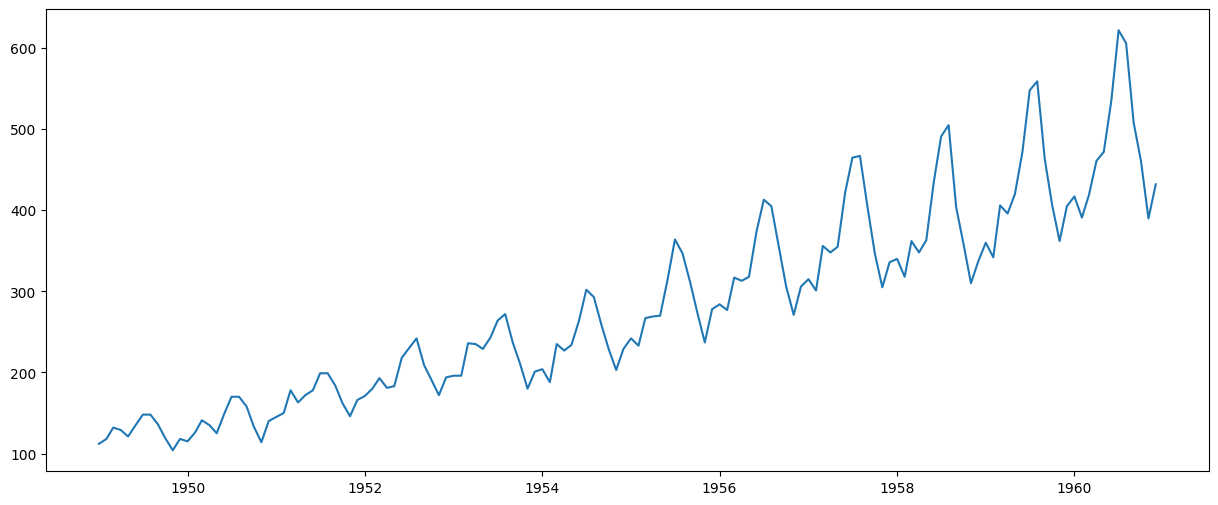

In [8]:
#Check Stationarity
plt.plot(ts)

Stationarity is a time series whose average, spread, and pattern stay the same over time (no trend, no changing volatility).

why do we test for stationarity
We test for it because a lot of forecasting models assume the data is stationary, and if you feed them non-stationary data without knowing it, they give you predictions that are wrong or misleading — without any obvious warning sign.

Stationarity test

In [9]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    rolmean = pd.Series(timeseries).rolling(window=12).mean()
    rolstd = pd.Series(timeseries).rolling(window=12).std()

    # plotting

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue', label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt. show(block=False)

    #Perform Dickey-Fuller test:
    print('Results.of .Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test.Statistic', 'p-value', '#Lags .Used', 'Number of Observations Used']) 
    for key,value in dftest[4].items():
        dfoutput['Critical .Value (%s) '%key] = value
    print(dfoutput)




In [10]:
ts

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, Length: 144, dtype: int64

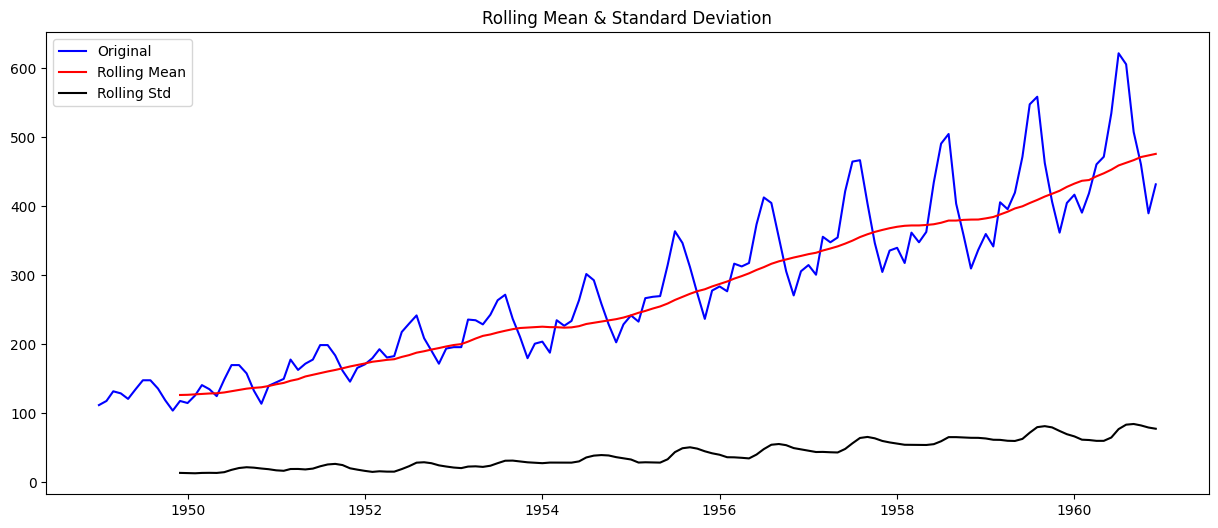

Results.of .Dickey-Fuller Test:
Test.Statistic                   0.815369
p-value                          0.991880
#Lags .Used                     13.000000
Number of Observations Used    130.000000
Critical .Value (1%)            -3.481682
Critical .Value (5%)            -2.884042
Critical .Value (10%)           -2.578770
dtype: float64


In [11]:
test_stationarity(ts)

MAKING TS STATIONARY

. Log Transformation
. Differencing
. Double Log
. Double Differencing
. Log + Differencing

After your forecasting is done, always do the inverse transformation

In [12]:
ts

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, Length: 144, dtype: int64

In [13]:
ts_log = np.log(ts)

In [14]:
ts_log.head(5)

Month
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
Name: #Passengers, dtype: float64

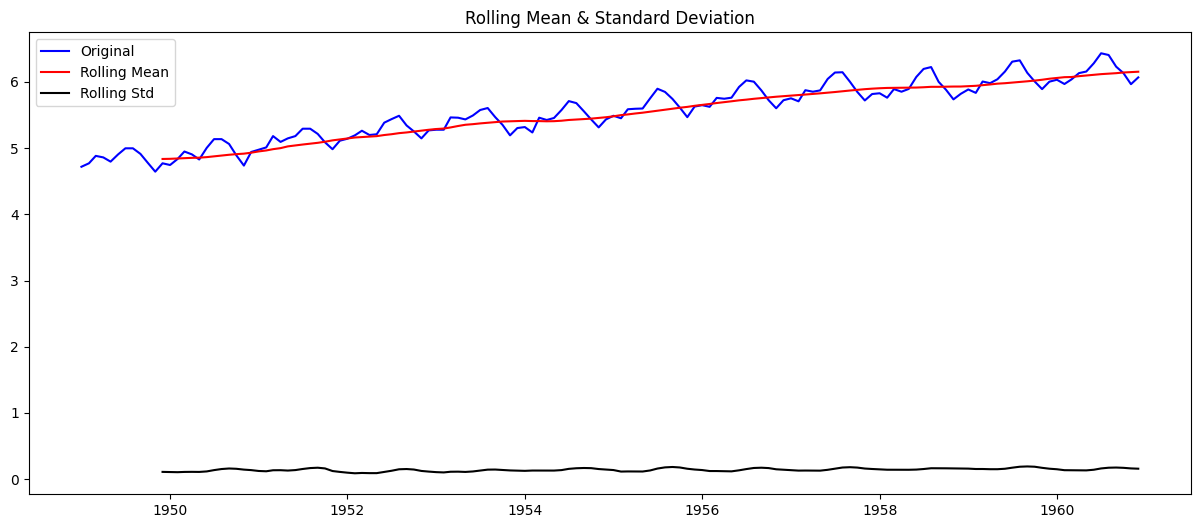

Results.of .Dickey-Fuller Test:
Test.Statistic                  -1.717017
p-value                          0.422367
#Lags .Used                     13.000000
Number of Observations Used    130.000000
Critical .Value (1%)            -3.481682
Critical .Value (5%)            -2.884042
Critical .Value (10%)           -2.578770
dtype: float64


In [15]:
test_stationarity(ts_log)

In [16]:
ts_doublelog = np.log(ts_log)

In [17]:
ts_doublelog

Month
1949-01-01    1.551491
1949-02-01    1.562490
1949-03-01    1.585719
1949-04-01    1.581000
1949-05-01    1.567739
                ...   
1960-08-01    1.857372
1960-09-01    1.829454
1960-10-01    1.813749
1960-11-01    1.786101
1960-12-01    1.803099
Name: #Passengers, Length: 144, dtype: float64

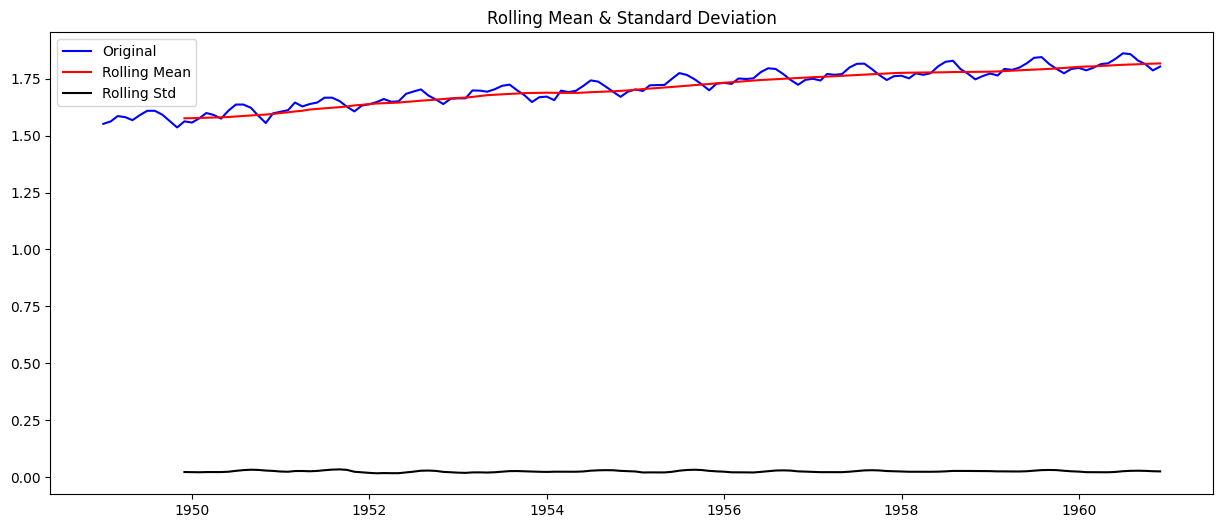

Results.of .Dickey-Fuller Test:
Test.Statistic                  -2.156028
p-value                          0.222590
#Lags .Used                     13.000000
Number of Observations Used    130.000000
Critical .Value (1%)            -3.481682
Critical .Value (5%)            -2.884042
Critical .Value (10%)           -2.578770
dtype: float64


In [18]:
test_stationarity(ts_doublelog)

Smoothing — averaging out short-term noise/fluctuations in a series so the underlying pattern is easier to see

Month
1949-12-01   -0.065494
1950-01-01   -0.093449
1950-02-01   -0.007566
1950-03-01    0.099416
1950-04-01    0.052142
Name: #Passengers, dtype: float64

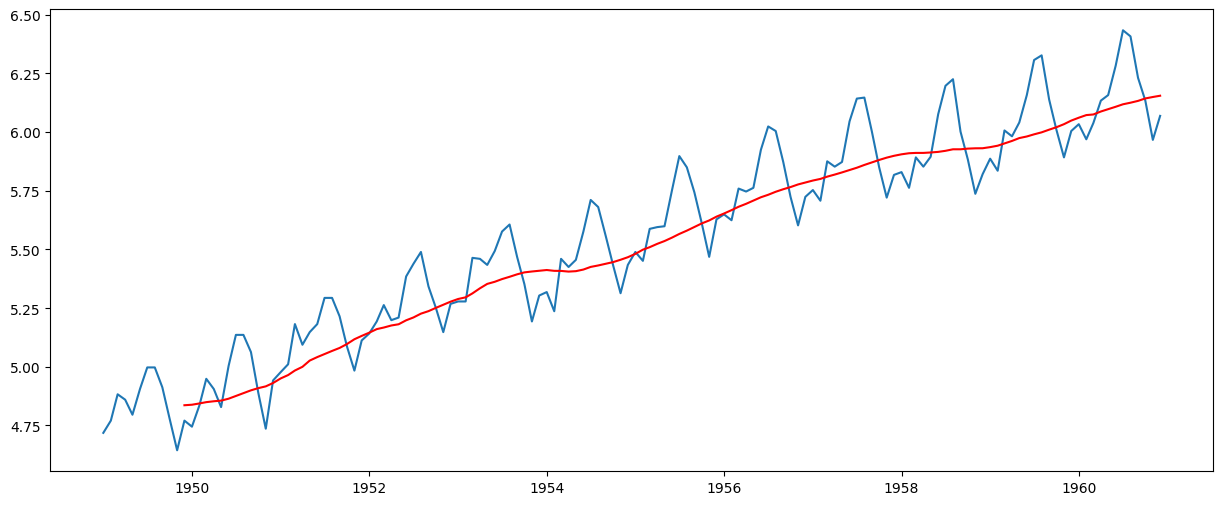

In [19]:
#Smoothing
moving_avg = pd.Series(ts_log).rolling(window=12).mean()
plt.plot(ts_log)
plt.plot(moving_avg, color='red')

ts_log_moving_avg_diff = ts_log - moving_avg
ts_log_moving_avg_diff.head(5)

ts_log_moving_avg_diff.dropna(inplace=True)
ts_log_moving_avg_diff.head(5)

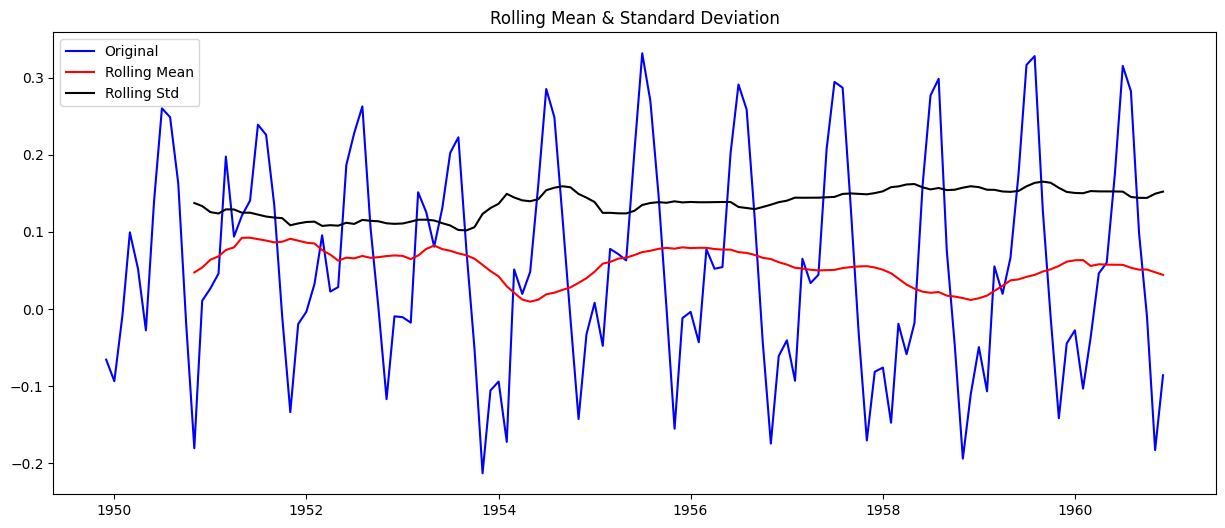

Results.of .Dickey-Fuller Test:
Test.Statistic                  -3.162908
p-value                          0.022235
#Lags .Used                     13.000000
Number of Observations Used    119.000000
Critical .Value (1%)            -3.486535
Critical .Value (5%)            -2.886151
Critical .Value (10%)           -2.579896
dtype: float64


In [20]:
test_stationarity(ts_log_moving_avg_diff)

Decomposition — breaking a time series into three parts:

Trend — the long-term direction (going up, down, or flat over time)
Seasonal — regular, repeating patterns tied to a fixed period (e.g., higher sales every December)
Residual — what's left over after removing trend and seasonal — the random "noise" the other two don't explain

DECOMPOSITION

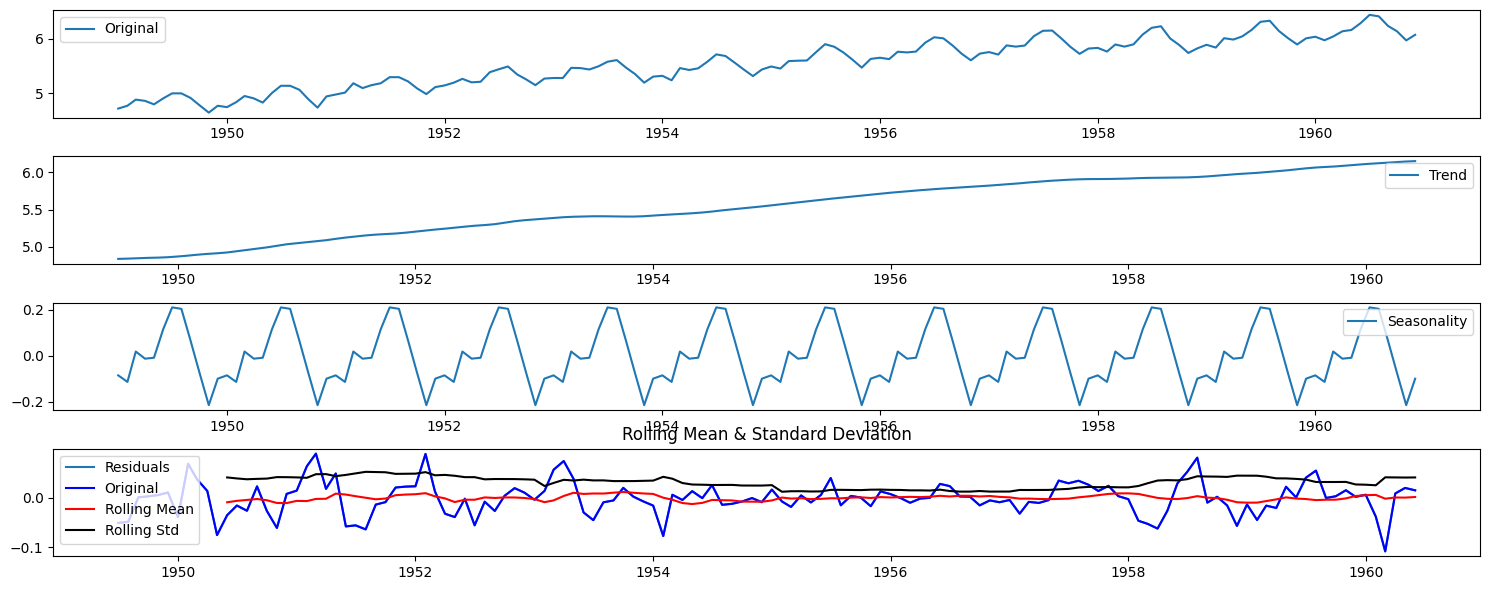

Results.of .Dickey-Fuller Test:
Test.Statistic                -6.332387e+00
p-value                        2.885059e-08
#Lags .Used                    9.000000e+00
Number of Observations Used    1.220000e+02
Critical .Value (1%)          -3.485122e+00
Critical .Value (5%)          -2.885538e+00
Critical .Value (10%)         -2.579569e+00
dtype: float64


In [21]:
from statsmodels. tsa. seasonal import seasonal_decompose
decomposition = seasonal_decompose(ts_log)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.subplot(411)
plt.plot(ts_log, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()

ts_log_decompose = residual
ts_log_decompose.dropna(inplace=True)
test_stationarity(ts_log_decompose)